In [1]:
import pennylane as qml
from pennylane import numpy as np
from scipy.optimize import minimize
import networkx as nx
from pyvis import network as pvnet
from matplotlib import pyplot as plt
plt.style.use('seaborn')

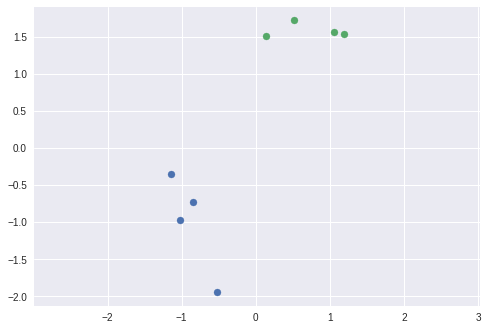

In [2]:
# set up two random distributions with n_points total points
n_points = 8
n1 = n_points//2
n2 = n_points//2
set1  = np.random.normal(-1, .5, (2, n1))
set2 = np.random.normal(1, .5, (2, n2))
plt.scatter(set1[0, :], set1[1, :])
plt.scatter(set2[0, :], set2[1, :])
plt.axis('equal')
plt.show()     

In [3]:
# create a dictionary mapping points to nodes
combined_set = np.hstack((set1, set2))
nodes_points = dict()
counter = 0
for column in range(combined_set.shape[1]):
    nodes_points[counter] = combined_set[:, column]
    counter += 1
nodes = nodes_points.keys()

# now set up edges between the nodes corresponding to distances between nodes
edges = []
for node1 in nodes:
    point1 = nodes_points[node1]
    for node2 in nodes:
        point2 = nodes_points[node2]
        for i in range(round(np.linalg.norm(point1 - point2))):
            edges.append((node1, node2))

# now draw the graph with the nodes and edges we've set up
G = nx.MultiGraph(edges)

In [4]:
# visualize our graph
def plot_g_pyviz(G, name='maxcut_graph.html', height='500px', width='800px'):
    g = G.copy() # some attributes added to nodes
    net = pvnet.Network(notebook=True, directed=True, height=height,
                        width=width)
    net.from_nx(g)
#     net.toggle_physics(False) #comment out for multiple edges between node pairs
    net.set_edge_smooth('dynamic')
    return net.show(name)
plot_g_pyviz(G)

In [5]:
n_wires = len(nodes)
graph = edges.copy()

#unitary operator U_B with parameter beta
def U_B(beta):
    for wire in range(n_wires):
        qml.RX(2 * beta, wires=wire)

#unitary operator U_C with parameter gamma
def U_C(gamma):
    for edge in graph:
        wire1 = edge[0]
        wire2 = edge[1]
        qml.CNOT(wires=[wire1, wire2])
        qml.RZ(gamma, wires=wire2)
        qml.CNOT(wires=[wire1, wire2])

In [6]:
#function for converting bitstring to base-10 integer
def bitstring_to_int(bit_string_sample):
    bit_string = "".join(str(bs) for bs in bit_string_sample)
    return int(bit_string, base=2)

In [7]:
#set up a device
dev = qml.device("default.qubit", wires=n_wires, shots=1)

In [8]:
#define the Pauli Z matrix and its Kronecker product w/itself
pauli_z = [[1, 0], [0, -1]]
pauli_z_2 = np.kron(pauli_z, pauli_z, requires_grad=False)

@qml.qnode(dev)
def circuit(gammas, betas, edge=None, n_layers=1):
    # apply Hadamards to get the n qubit |+> state
    for wire in range(n_wires):
        qml.Hadamard(wires=wire)
    # p instances of unitary operators
    for i in range(n_layers):
        U_C(gammas[i])
        U_B(betas[i])
    if edge is None:
        # measurement phase
        return qml.sample()
    # during the optimization phase we are evaluating a term
    # in the objective using expval
    return qml.expval(qml.Hermitian(pauli_z_2, wires=edge))

In [9]:
def qaoa_maxcut(n_layers=1):
    print("\np={:d}".format(n_layers))

    # initialize the parameters near zero
    init_params = 0.01 * np.random.rand(2, n_layers, requires_grad=True)

    # minimize the negative of the objective function
    def objective(params):
        gammas = params[0]
        betas = params[1]
        neg_obj = 0
        for edge in graph:
            # objective for the MaxCut problem
            neg_obj -= 0.5 * (1 - circuit(gammas, betas, edge=edge, n_layers=n_layers))
        return neg_obj

    # initialize optimizer: Adagrad works well empirically
    opt = qml.AdagradOptimizer(stepsize=0.5)

    # optimize parameters in objective
    params = init_params
    steps = 40
    for i in range(steps):
        params = opt.step(objective, params)
        if (i + 1) % 10 == 0:
            print("Objective after step {:10d}: {: .7f}".format(i + 1, -objective(params)))

    # sample measured bitstrings 100 times
    bit_strings = []
    n_samples = 1000
    for i in range(0, n_samples):
        bit_strings.append(bitstring_to_int(circuit(params[0], params[1], edge=None, n_layers=n_layers)))

    # print optimal parameters and most frequently sampled bitstring
    counts = np.bincount(np.array(bit_strings))
    most_freq_bit_string = np.argmax(counts)
    print("Optimized (gamma, beta) vectors:\n{}".format(params[:, :n_layers]))
    print("Optimal Objective:", -objective(params))
    print("Most frequently sampled bit string is: {:08b}".format(most_freq_bit_string))

    return -objective(params), bit_strings

# perform qaoa on our graph with p=1,2 and
# keep the bitstring sample lists
bitstrings1 = qaoa_maxcut(n_layers=1)[1]
# bitstrings2 = qaoa_maxcut(n_layers=3)[1]


p=1


KeyboardInterrupt: 

In [ ]:
yticks = range(0, 2**n_wires)
ytick_labels = list(map(lambda x: format(x, '08b'), yticks))
bins = np.arange(0, 2**n_wires+1) - 0.5

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 30))
plt.subplot(2, 1, 1)
plt.title("Single Layer", fontsize=26)
plt.ylabel("Bitstring", fontsize=16)
plt.xlabel("Frequency", fontsize=16)
plt.yticks(yticks, ytick_labels, rotation="horizontal")
plt.hist(bitstrings1, bins=bins, orientation='horizontal')
# plt.subplot(2, 1, 2)
# plt.title("3 Layers", fontsize=26)
# plt.ylabel("Bitstring", fontsize=16)
# plt.xlabel("Frequency", fontsize=16)
# plt.yticks(yticks, ytick_labels, rotation="horizontal")
# plt.hist(bitstrings2, bins=bins, orientation='horizontal')
# plt.tight_layout()
# plt.show()